In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
transform = transforms.Compose([transforms.ToTensor()])  # [0,1] range

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def add_gaussian_noise(img, std=0.1):
    noise = torch.randn_like(img) * std
    return torch.clamp(img + noise, 0.0, 1.0)

def add_salt_pepper_noise(img, prob=0.05):
    noisy = img.clone()
    salt = torch.rand_like(img) < (prob / 2)
    pepper = torch.rand_like(img) < (prob / 2)
    noisy[salt] = 1.0
    noisy[pepper] = 0.0
    return noisy

# Helper to get noisy image
def get_noisy(clean, noise_type='gaussian', level=0.1):
    if noise_type == 'gaussian':
        return add_gaussian_noise(clean, std=level)
    else:
        return add_salt_pepper_noise(clean, prob=level)

/home/silicon/dip_ai/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [3]:
class DAE_Transposed(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder (can deepen by adding more conv+pool)
        self.enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # Decoder (transposed conv)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.up2 = nn.ConvTranspose2d(64, 3, 2, stride=2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.enc1(x))
        x = self.pool(x)
        x = self.relu(self.enc2(x))
        x = self.pool(x)
        x = self.relu(self.up1(x))
        x = self.sigmoid(self.up2(x))
        return x

In [4]:
class DAE_Unpool(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_enc1 = nn.Conv2d(3, 64, 3, padding=1)
        self.conv_enc2 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2, 2)
        self.conv_dec1 = nn.Conv2d(128, 64, 3, padding=1)
        self.conv_dec2 = nn.Conv2d(64, 3, 3, padding=1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv_enc1(x))
        x, idx1 = self.pool(x)          # 32→16
        x = self.relu(self.conv_enc2(x))
        x, idx2 = self.pool(x)          # 16→8
        x = self.unpool(x, idx2)        # 8→16
        x = self.relu(self.conv_dec1(x))
        x = self.unpool(x, idx1)        # 16→32
        x = self.sigmoid(self.conv_dec2(x))
        return x

In [7]:

def train_dae(model, loader, noise_type='gaussian', level=0.1, epochs=10, lr=0.001):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for data, _ in loader:                  # ignore class labels
            clean = data.to(device)
            noisy = get_noisy(clean.cpu(), noise_type, level).to(device)
            recon = model(noisy)
            loss = criterion(recon, clean)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        history.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs} | MSE: {avg_loss:.4f}')
    return history

In [6]:
def evaluate_and_visualize(model, loader, noise_type='gaussian', level=0.1, num=5):
    model.eval()
    data_iter = iter(loader)
    clean, _ = next(data_iter)
    clean = clean[:num].to(device)
    noisy = get_noisy(clean.cpu(), noise_type, level).to(device)
    with torch.no_grad():
        recon = model(noisy)

    # Plot
    fig, axs = plt.subplots(3, num, figsize=(12, 6))
    for i in range(num):
        axs[0, i].imshow(clean[i].cpu().permute(1,2,0))
        axs[0, i].set_title('Clean')
        axs[0, i].axis('off')
        axs[1, i].imshow(noisy[i].cpu().permute(1,2,0))
        axs[1, i].set_title('Noisy')
        axs[1, i].axis('off')
        axs[2, i].imshow(recon[i].cpu().permute(1,2,0))
        axs[2, i].set_title('Denoised')
        axs[2, i].axis('off')
    plt.tight_layout()
    plt.show()

# Example usage after training:
# history = train_dae(model, train_loader, 'gaussian', 0.2, epochs=20)
# evaluate_and_visualize(model, test_loader, 'gaussian', 0.2)

Epoch 1/10 | MSE: 0.0074
Epoch 2/10 | MSE: 0.0036
Epoch 3/10 | MSE: 0.0030
Epoch 4/10 | MSE: 0.0026
Epoch 5/10 | MSE: 0.0023
Epoch 6/10 | MSE: 0.0021
Epoch 7/10 | MSE: 0.0020
Epoch 8/10 | MSE: 0.0018
Epoch 9/10 | MSE: 0.0017
Epoch 10/10 | MSE: 0.0016


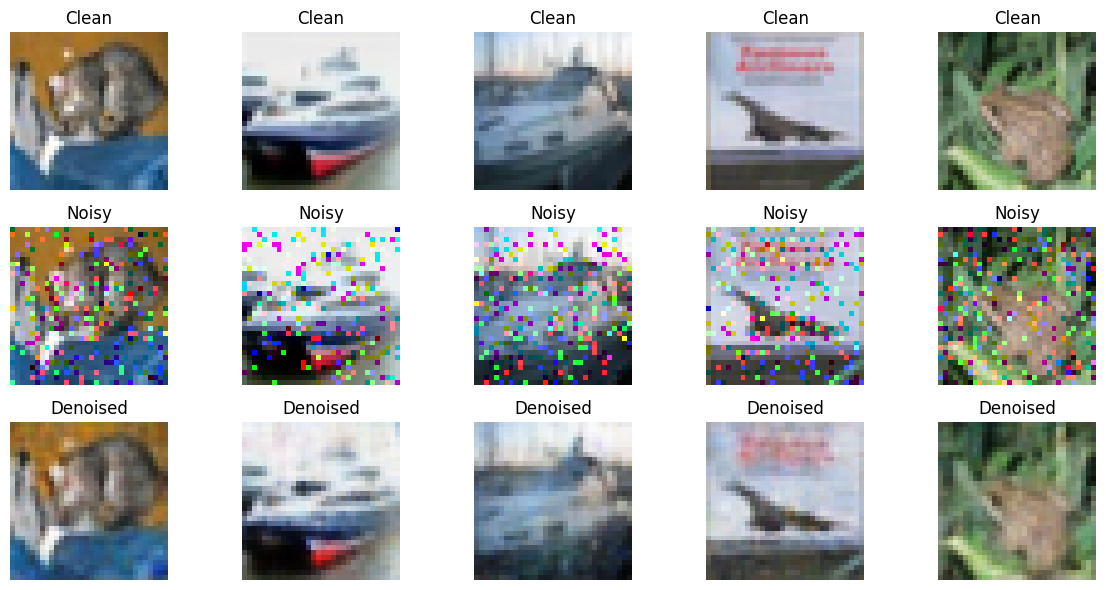

In [11]:
model = DAE_Unpool()
history = train_dae(model, train_loader, noise_type='kk', level=0.1, epochs=10)
evaluate_and_visualize(model, test_loader, noise_type='kk', level=0.1)